<a href="https://colab.research.google.com/github/MichelLLIUU/Hands-on-ML-with-Pytorch/blob/main/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

end-to-end

纵观全局。

获取数据。

探索数据并将其可视化，以获得洞察力。

为机器学习算法准备数据。

选择一个模型并对其进行训练。

微调模型

展示解决方案。

启动、监控和维护系统。

https://github.com/ageron/handson-mlp/blob/main/ml-project-checklist.md

管道
数据处理组件的序列称为数据管道 。流水线在机器学习系统中非常常见，因为有大量数据需要处理，许多数据转换需要应用。

组件通常异步运行。每个组件都会拉入大量数据，对其进行处理，并在另一个数据存储中吐出结果。然后，一段时间后，管道中的下一个组件会输入这些数据，并输出自己的结果。每个组件都相当独立：组件之间的接口只是数据存储。这使得系统易于掌握（在数据流图的帮助下），不同的团队可以专注于不同的组件。此外，如果某个组件发生故障，下游组件通常可以继续正常运行（至少暂时如此），只需使用故障组件的最后输出即可。这使得架构相当稳健。

另一方面，如果不实施适当的监控，损坏的组件可能会在一段时间内被忽视。数据会变得陈旧，整个系统的性能也会下降。

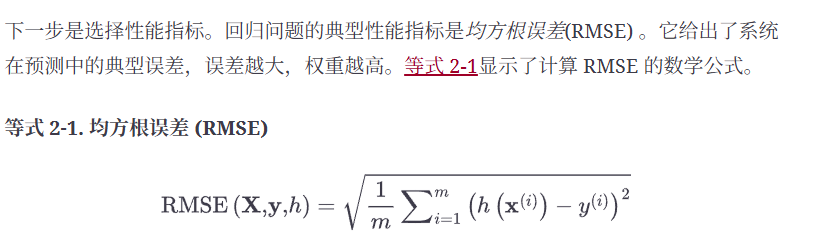

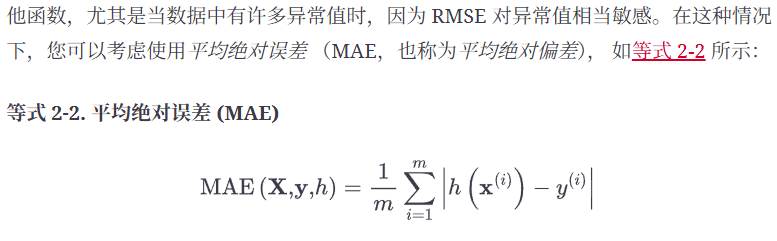

https://colab.research.google.com/github/ageron/handson-mlp/blob/main/02_end_to_end_machine_learning_project.ipynb

https://colab.research.google.com/github/ageron/handson-mlp/blob/main/

In [1]:
#本地没有数据 → 从网上下载 → 解压 → 用 Pandas 读取成 DataFrame

from pathlib import Path
import pandas as pd
import tarfile
import urllib.request


def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

In [2]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# check the ocean_proximity

housing_full["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [5]:
# check the distribution of all data
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


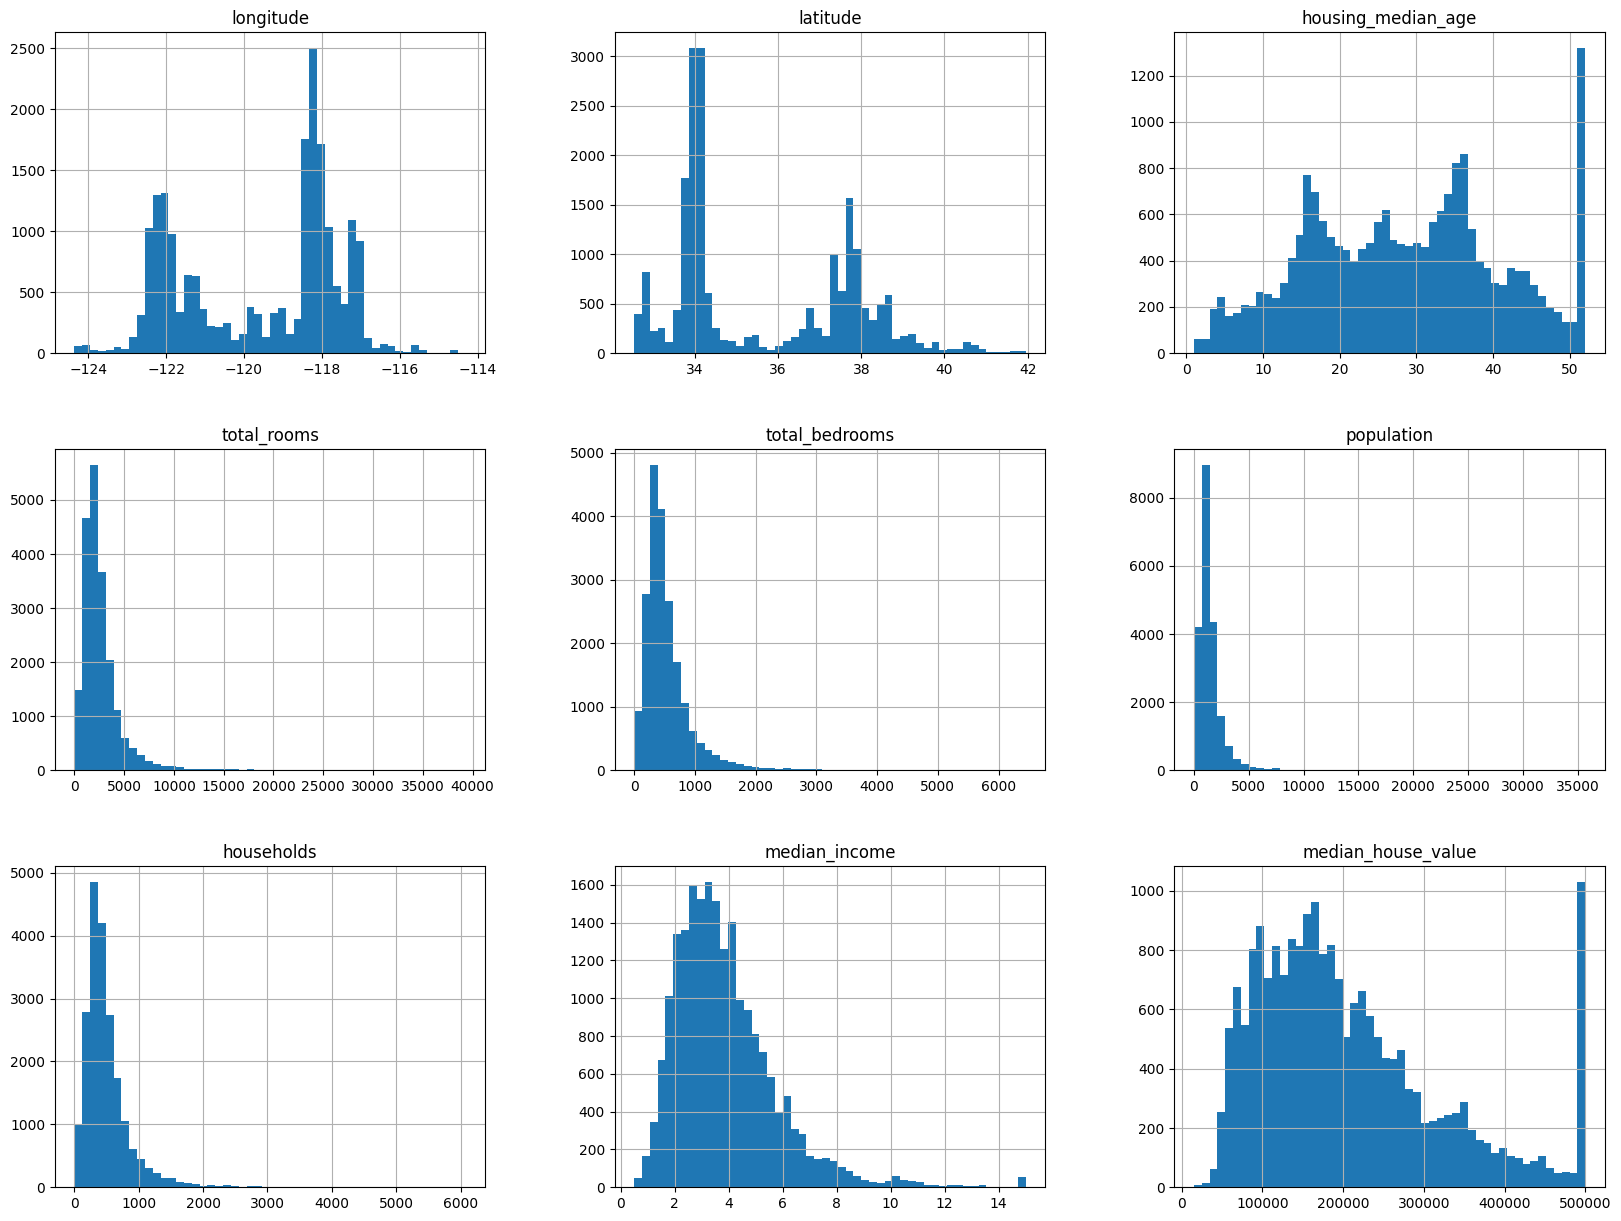

In [6]:
import matplotlib.pyplot as plt
housing_full.hist(bins=50, figsize=(20,15))
plt.show()

In [7]:
# create train_set

import numpy as np

def shuffle_and_split_data(data, test_ration, rng):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ration)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]
"""
1. 生成随机索引顺序(rng+shuffled_indices,在不改变源数据的前提下改变顺序，并且在rng固定seed下，可以使结果可复现)
2. 按比例切一部分做 test
3. 剩下做 train
4. 用索引去取数据 iloc = “按位置取数据”（index location）
"""

'\n1. 生成随机索引顺序(rng+shuffled_indices,在不改变源数据的前提下改变顺序，并且在rng固定seed下，可以使结果可复现)\n2. 按比例切一部分做 test\n3. 剩下做 train\n4. 用索引去取数据 iloc = “按位置取数据”（index location）\n'

In [8]:
rng = np.random.default_rng(seed=42)
train_set, test_set = shuffle_and_split_data(housing_full,0.2,rng)

len(train_set), len(test_set)

(16512, 4128)

**方法是按“当前位置 + 随机打乱后的顺序”来分训练集/测试集的**，而不是按“样本自身的固定身份”来分。
所以一旦数据集更新，哪怕只是多了几条数据，原来很多样本也可能被重新分配。

---

# 一、先回忆之前的方法在做什么

之前的代码大意是：

1. 先把所有样本的行号打乱
2. 取前 20% 做测试集
3. 剩下做训练集

也就是它依赖的是：

* `len(data)`：数据总数
* 样本在当前数据表中的位置
* 随机排列后的顺序

---

# 二、为什么数据一更新就会失效？

因为**随机切分是针对“当前整张表”做的**。

假设原来有 10 条数据：

```text
A B C D E F G H I J
```

打乱后选 20% 做测试集，比如得到：

```text
测试集: C, H
训练集: 其他
```

---

现在新来了 2 条数据：

```text
A B C D E F G H I J K L
```

你再重新打乱并切分，即使随机种子不变，也是在对 **12 条数据** 做 permutation，不再是对原来的 10 条数据做。

于是：

* 原来的排列顺序会变
* 前 20% 的边界也变了
* 原来在测试集的样本可能跑到训练集
* 原来在训练集的样本也可能跑到测试集

---

# 三、为什么“固定 seed”也没用？

这是很多人最容易误解的地方。

固定 seed 只能保证：

> **对于同一份数据，随机结果可复现**

它不能保证：

> **当数据内容或长度变了以后，旧样本还留在原来的集合里**

因为随机数生成器虽然还是同一个 seed，但你现在输入给它的是：

* 原来：10 个位置
* 现在：12 个位置

排列对象已经变了，所以结果自然变了。

---

# 四、这会带来什么问题？

最主要的问题是：

## 1. 训练/测试划分不稳定

同一个旧样本，这次在训练集，下次可能进测试集。

## 2. 评估结果不可比

你这次和下次测试的不是同一批样本，模型分数不好直接比较。

## 3. 可能造成数据泄露

某个样本以前进过训练集，后来又跑到测试集，会让测试结果显得过于乐观。

---

# 五、为什么“按唯一标识符哈希”就不会失效？

因为这种方法不是看“它在表里排第几”，而是看：

> **它自己是谁**

比如每个样本有唯一 ID：

```text
ID = 1001, 1002, 1003 ...
```

你对每个 ID 算哈希，再规定：

* 哈希值落在前 20% → 测试集
* 否则 → 训练集

这样只要这个样本的 ID 不变，它就永远分到同一个集合。

所以即使以后数据集新增了很多新样本：

* 老样本不会变来变去
* 新样本只会根据自己的 ID 被分配
* 划分稳定

---

# 六、一句话总结

之前的方法会失效，是因为它依赖**当前数据集的整体长度和随机顺序**来划分；一旦数据集更新，旧样本的相对位置和随机排列就会改变，所以原来的训练/测试划分无法保持稳定。

如果你愿意，我可以接着给你举一个“10条数据变12条数据”的具体 permutation 小例子，让你一眼看出为什么旧样本会换组。


所以，这种解决方案无论是否固定seed都会在下一次获取更新数据集时失效。为了在更新数据集后仍能保持稳定的训练/测试分割，一种常见的解决方案是使用每个实例的标识符来决定是否将其放入测试集（假设实例具有唯一且不可变的标识符）。例如，可以计算每个实例标识符的哈希值，如果哈希值小于或等于最大哈希值的 20%，则将该实例放入测试集中。这样可以确保测试集在多次运行中保持一致，即使刷新数据集也是如此。新的测试集将包含 20% 的新实例，但不会包含之前在训练集中的任何实例。

下面是一种可能的实现方法：

from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]
遗憾的是，住房数据集没有标识符列。最简单的解决方案是使用行索引作为标识符：

housing_with_id = housing_full.reset_index()  # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")
如果使用行索引作为唯一标识符，则需要确保新数据被添加到数据集的末尾，并且不会删除任何行。如果无法做到这一点，那么可以尝试使用最稳定的特征来建立唯一标识符。例如，一个地区的经度和纬度可以保证稳定几百万年，因此可以像这样将它们组合成一个 ID。7

housing_with_id["id"] = (housing_full["longitude"] * 1000
                         + housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")
Scikit-Learn 提供了一些函数，可以通过各种方式将数据集拆分成多个子集。最简单的函数是train_test_split() ，它的功能与我们之前定义的shuffle_and_split_data() 函数基本相同，但多了几个功能。首先，它有一个random_state 参数，允许你设置随机发生器的种子。其次，您可以将具有相同行数的多个数据集传递给它，它将在相同的索引上对它们进行拆分（这非常有用，例如，如果您有一个单独的 DataFrame 用于标签）：

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

--------------------------------------------------------------


假设你和一些专家聊过，他们告诉你收入中位数是预测房价中位数的一个非常重要的属性。你可能希望确保测试集能够代表整个数据集中的各类收入。由于收入中位数是一个连续的数字属性，因此首先需要创建一个收入类别属性。

让我们更仔细地观察一下收入中位数柱状图（回到图 2-8 中）：大多数收入中位数值都集中在 1.5 到 6 左右（即 15,000 美元到 60,000 美元），但也有一些收入中位数远远超过了 6。在数据集中，每个阶层都必须有足够数量的实例，否则对阶层重要性的估计可能会有偏差。这意味着您的分层数量不应过多，每个分层都应足够大。下面的代码使用pd.cut() 函数创建了一个包含五个类别（从 1 到 5）的收入类别属性；类别 1 从 0 到 1.5（即小于 15000 美元），类别 2 从 1.5 到 3，以此类推：


In [9]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

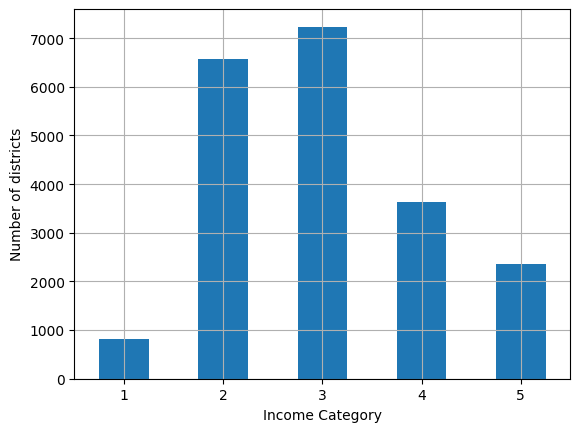

In [10]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot = 0, grid = True)
plt.xlabel("Income Category")
plt.ylabel("Number of districts")
plt.show()

现在就可以按照收入层级来进行分层取样。

sklearn.model_selection 软件包中提供了许多分割器类，可以实现将数据集分割成训练集和测试集的各种策略。每个分割器都有一个split() 方法，用于返回同一数据的不同训练/测试分割的迭代器。

split() 方法产生的是训练和测试索引，而不是数据本身。

In [11]:
#第一种方法
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full, housing_full["income_cat"]):#分层抽样
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n = housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])
strat_train_set, strat_test_set = strat_splits[0]

# #第二种方法
# strat_train_set, strat_test_set = train_test_split(
#     housing_full, test_size=0.2, stratify=housing_full["income_cat"],
#     random_state=42)

现在回归原始结构，删除掉income_cat

In [12]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

/tmp/ipykernel_4586/1299016719.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True)
/tmp/ipykernel_4586/1299016719.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True)


In [13]:
housing = strat_train_set.copy()

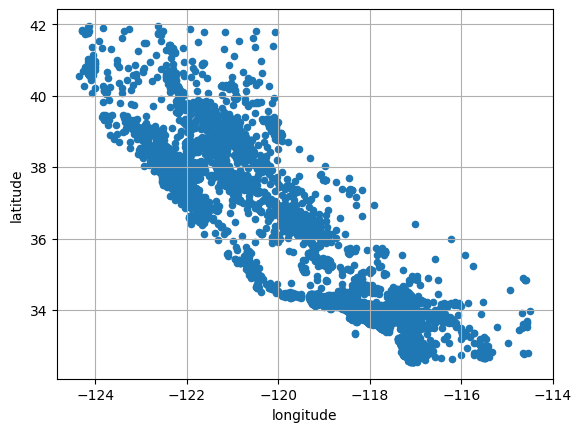

In [14]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
plt.show()

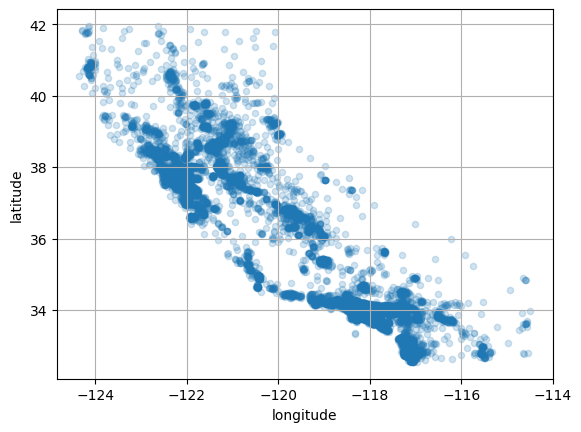

In [15]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)#alpha使得数据点密度高的地方更容易可视化
plt.show()

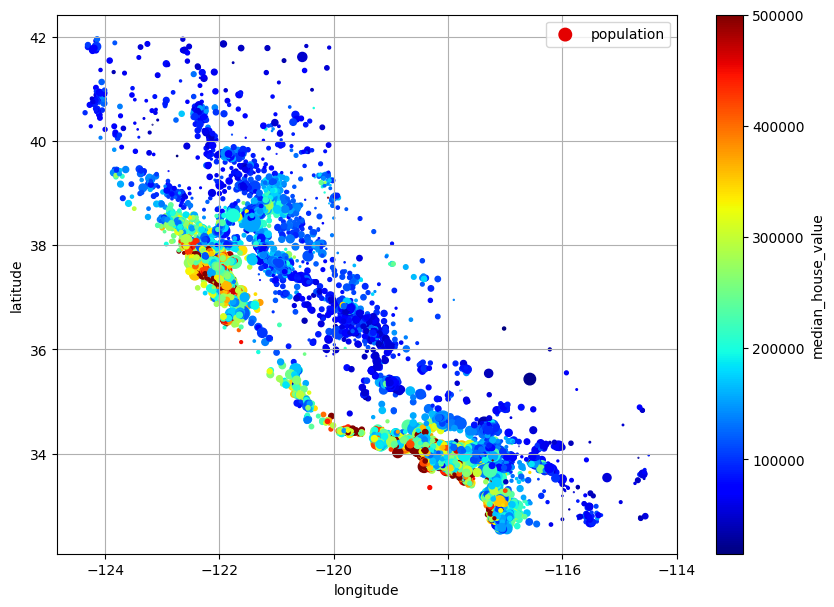

In [16]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()
#房价与地理位置（如靠近海洋）和人口密度的关系
#不过在北加州，沿海地区的房价并不高，所以这并不是一个简单的规则。

In [17]:
#寻找相关性
corr_matrix = housing.corr(numeric_only = True)

corr_matrix["median_house_value"].sort_values(ascending=False)
#当系数接近 1 时，表示存在很强的正相关性

,median_house_value
median_house_value,1.000000
median_income,0.688380
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
longitude,-0.050859
latitude,-0.139584


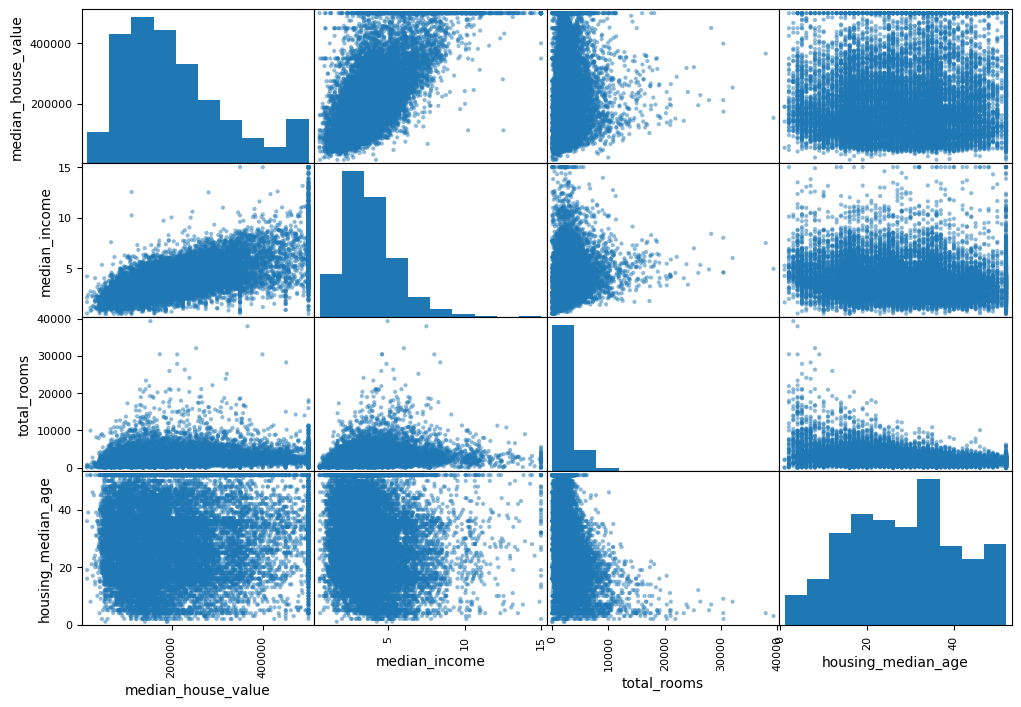

In [18]:
#或者用pandas来可视化不同变量间的散点图（数据分布）
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()

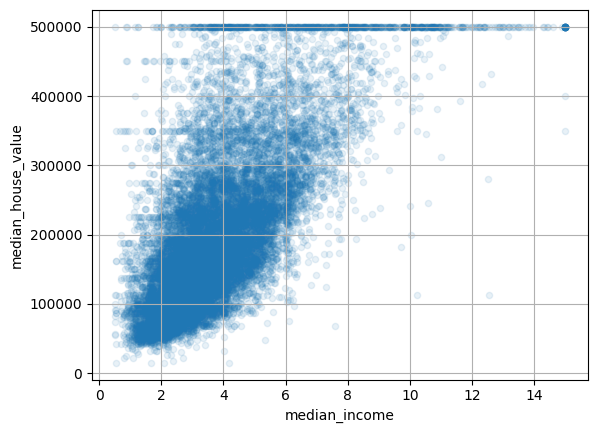

In [19]:
#从相关性散点图来看，最有希望预测房屋价值中位数的属性似乎是收入中位数

housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()

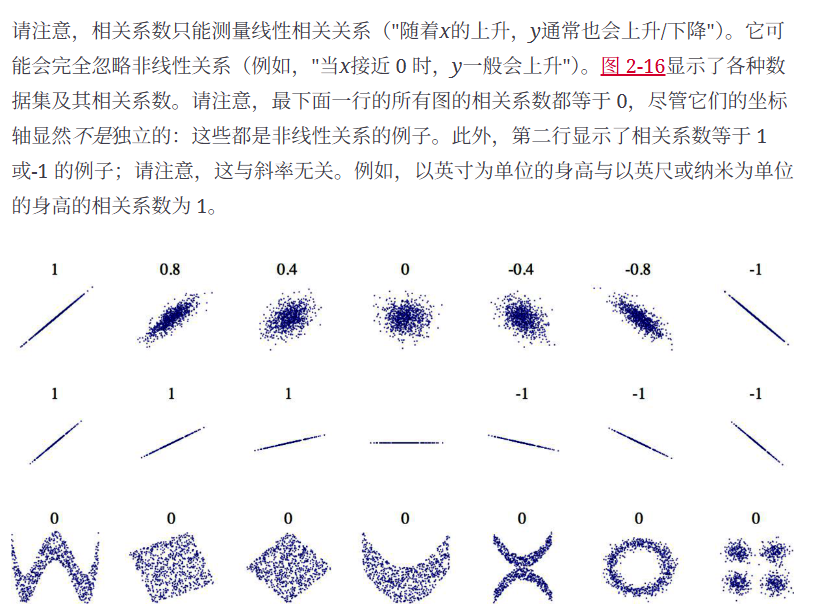

# **属性组合实验**

在将数据输入机器学习算法之前可能需要清理的数据怪癖，还发现了属性之间有趣的相关性，尤其是与目标属性之间的相关性。

**尝试各种属性组合**

***例如，如果不知道有多少家庭，那么一个地区的房间总数就不是很有用。真正需要的是每个家庭的房间数。***

警告
创建新的组合特征时，确保它们与现有特征的线性相关性不强：共线性会导致某些模型（如线性回归）出现问题。尤其要避免对现有特征进行简单的加权求和。 **texte en gras**

In [20]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_house,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_house,-0.038224
longitude,-0.050859


新属性bedrooms_ratio 与房屋价值中位数的相关性远高于房间或卧室总数。这是一个很强的负相关，所以看起来卧室/房间比例越低的房子越贵。每户的房间数也比一个地区的房间总数更有参考价值--很明显，房子越大，价格越贵。

为机器学习算法准备数据
现在是为机器学习算法准备数据的时候了。与其手动完成这项工作，不如为此编写函数，原因有以下几点：

这样，您就可以在任何数据集上轻松重现这些转换（例如，在下一次获得新数据集时）。

您将逐步建立一个转换函数库，以便在未来的项目中重复使用。

您可以在您的实时系统中使用这些函数来转换新数据，然后再将其输入到您的算法中。

这样，您就可以轻松尝试各种转换，看看哪种转换组合效果最好。

但首先要恢复到一个干净的训练集（再次复制strat_train_set ）。您还应该将预测值和标签分开，因为您不一定希望对预测值和目标值应用相同的转换（注意drop() 会创建数据副本，不会影响strat_train_set ） ：

In [21]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

清理数据
大多数 机器学习算法无法处理缺失的特征，因此您需要处理这些数据。例如，您之前注意到total_bedrooms 属性有一些缺失值。有三种方法可以解决这个问题：

删除相应的地区。

删除整个属性。

将缺失值设置为某个值（零、平均值、中位数等）。这就是所谓的估算。

您可以使用 Pandas DataFrame的dropna() ,drop() 和fillna() 方法来轻松实现：

In [ ]:
# housing.dropna(subset=["total_bedrooms"], inplace=True)  # option 1

# housing.drop("total_bedrooms", axis=1, inplace=True)  # option 2

# median = housing["total_bedrooms"].median()  # option 3
# housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)

您决定选择方案 3，因为它的破坏性最小，但您将使用一个方便的 Scikit-Learn 类来代替前面的代码：SimpleImputer 。这样做的好处是，它可以存储每个特征的中值：这样不仅可以对训练集，还可以对验证集、测试集以及模型中的任何新数据进行缺失值补偿。要使用它，首先需要创建一个SimpleImputer 实例，指定要用该属性的中位数替换每个属性的缺失值：

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

由于中位数只能在数值属性上计算，因此您需要创建一个仅包含数值属性的数据副本（这将排除文本属性ocean_proximity ）：

In [23]:
housing_num = housing.select_dtypes(include=[np.number])

In [24]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [30]:
print(imputer.statistics_)

housing_num.median().values

#课件imputer在fit后正确计算出了源数据的各特征值的median

[-118.51     34.26     29.     2125.      434.     1167.      408.
    3.5385]


array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

| 阶段 | 数据预处理（Imputer） | 机器学习模型      |
| -- | -------------- | ----------- |
| 学习 | `fit()`        | `fit()`     |
| 应用 | `transform()`  | `predict()` |


In [29]:
X = imputer.transform(housing_num)

缺失值也可以用平均值 (strategy="mean") 或最常出现的值 (strategy="most_frequent") 或常量值 (strategy="constant", fill_value=...) 替换。后两种策略支持非数值数据。

提示
sklearn.​impute 软件包中还有功能更强大的 imputers（均只适用于数值特征）：

KNNImputer 将每个缺失值替换为该特征的k 个近邻值的平均值。距离基于所有可用特征。

IterativeImputer 基于所有其他可用特征，为每个特征训练一个回归模型来预测缺失值。然后在更新的数据上再次训练模型，并多次重复这一过程，在每次迭代中改进模型和替换值

Scikit-Learn 转换器输出 NumPy 数组s（有时也输出 SciPy 稀疏矩阵），即使将 Pandas DataFrames 作为输入也是如此。11因此，imputer.transform(housing_num) 的输出是一个 NumPy 数组：X 既没有列名，也没有索引。幸运的是，用 DataFrame 封装X 并从housing_num 恢复列名和索引并不难：

In [ ]:
# housing_tr = pd.DataFrame(X, columns=housing_num.columns,
#                           index=housing_num.index)

处理文本和分类属性

In [31]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


它不是任意文本：可能的值数量有限，每个值代表一个类别。因此，这个属性是一个分类属性。 大多数机器学习算法更喜欢使用数字，因此让我们将这些类别从文本转换为数字。为此，我们可以使用 Scikit-Learn 的OrdinalEncoder 类：

In [32]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)#fit和transform的联合版

In [33]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [34]:
#您可以使用categories_ 实例变量获取类别列表。这是一个包含每个分类属性类别的一维数组的列表（在本例中，由于只有一个分类属性，因此该列表只包含一个数组）：
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

这种表示方法存在的一个问题是，ML 算法会假定两个相近的值比两个相远的值更相似。这在某些情况下可能没有问题（例如，对于 "差"、"一般"、"好 "和 "优 "等有序类别），但对于ocean_proximity 列显然不是这样（例如，类别 0 和 4 显然比类别 0 和 1 更相似）。

为了解决这个问题，常见的解决方案是为每个类别创建一个二进制属性：当类别为"<1H OCEAN" 时，一个属性等于 1（否则为 0），当类别为"INLAND" 时，另一个属性等于 1（否则为 0），以此类推。

这就是所谓的单热编码，因为只有一个属性等于 1（热），而其他属性等于 0（冷）。新属性有时被称为虚属性 。Scikit-Learn 提供了一个OneHotEncoder 类 ，用于将分类值转换为单热向量：


In [35]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [36]:
housing_cat_1hot #输出是 SciPy稀疏矩阵 ，而不是 NumPy 数组

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [37]:
housing_cat_1hot.toarray()
#它可以节省大量内存，加快计算速度。稀疏矩阵可以像普通二维数组一样使用。

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

或者，你也可以在创建OneHotEncoder 时设置sparse_output=False ，在这种情况下，transform() 方法将直接返回一个普通（稠密）NumPy 数组：

In [38]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

# **特征缩放和变换**
您需要对数据进行的最重要的转换之一 是特征缩放。除少数情况外，当输入数字属性的比例非常不同时，机器学习算法的表现并不好。住房数据就是这种情况：房间总数的范围从 6 到 39,320 不等，而收入中位数的范围只有 0 到 15。如果不进行任何缩放，大多数模型都会偏向于忽略收入中位数，而更多地关注房间数量。

警告
与所有估计器一样，重要的是仅将标度器用于训练数据：切勿将fit() 或fit_transform() 用于训练集之外的任何其他数据。

一旦有了训练好的标度器，就可以用它来transform() 任何其他集，包括验证集、测试集和新数据。需要注意的是，虽然训练集的值总是会按指定范围缩放，但如果新数据包含异常值，这些异常值最终可能会超出缩放范围。如果想避免这种情况，只需将clip 超参数设置为True 。

In [39]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

**另外一种**

**标准化 **

不同：首先减去平均值（因此标准化值的平均值为零），然后将结果除以标准差（因此标准化值的标准差等于 1）。与最小-最大缩放不同，标准化不会将数值限制在特定范围内。不过，标准化方法受异常值的影响要小得多。例如，假设一个地区的收入中位数等于 100（误），而不是通常的 0-15。如果将最小值-最大值缩放至 0-1 范围，就会将这个异常值缩放至 1，并将所有其他值缩放至 0-0.15，而标准化则不会受到太大影响。Scikit-Learn 提供了一个名为StandardScaler 的转换器，用于标准化 ：

In [40]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

提示
如果想缩放稀疏矩阵 而不先将其转换为密集矩阵 ，可以使用StandardScaler ，并将其with_mean 超参数设置为False ：它将只除以数据的标准差，而不减去平均值（因为这会破坏稀疏性）。

# 当一个特征的分布具有严重的尾部 时（即远离均值的值并不是指数级罕见值），最小-最大缩放和标准化都会将大多数值压制在一个很小的范围内

机器学习模型通常完全不喜欢这种情况，第 4 章中您将看到这一点。因此，在对特征进行缩放之前，应首先对其进行变换，以缩小重尾，并尽可能使分布大致对称。例如，对于尾部偏右的正特征，常用的方法是用其平方根来代替特征（或将特征提升到 0 和 1 之间的幂次）。如果特征的尾部很长很重，如幂律分布 ，那么用对数替换特征可能会有帮助。例如，population 特征大致遵循幂律：拥有 10,000 名居民的地区比拥有 1,000 名居民的地区的频率低 10 倍，而不是呈指数降低。图 2-17显示了计算其对数后，该特征看起来要好得多：它非常接近高斯分布 （即钟形）。

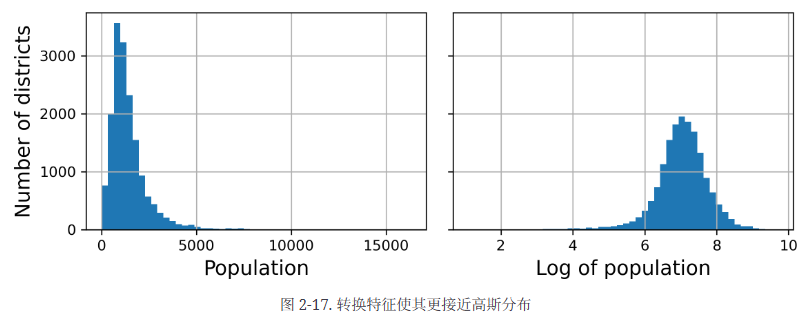


另一种处理重尾特征的方法是将 特征桶化。这意味着将其分布切成大小大致相同的桶，并用其所属桶的索引替换每个特征值，就像我们创建income_cat 特征时所做的那样（尽管我们只将其用于分层抽样）。例如，可以用百分位数替换每个值。使用大小相等的桶进行分层后，特征的分布几乎是均匀的，因此不需要进一步缩放，也可以直接除以桶的数量，将数值强制限制在 0-1 的范围内。

当某一特征具有多模态分布 （即有两个或两个以上明显的峰值，称为模态） ，如housing_median_age 特征，对其进行桶化也会有所帮助，但此时要将桶 ID 视为类别，而不是数值。这意味着必须对数据桶索引进行编码，例如使用OneHotEncoder （因此通常不希望使用过多的数据桶）。这种方法可以让回归模型更容易地针对该特征值的不同范围学习不同的规则。例如，也许建于 35 年前的房子有一种过时的特殊风格，因此它们的价格比单从房龄来看要便宜。

转换多模态分布的另一种方法是为每个模态（至少是主要模态）添加一个特征，表示住房中位年龄与该特定模态之间的相似性。相似性度量通常使用径向基函数(RBF)-任何仅取决于输入值与固定点之间距离的函数。最常用的 RBF 是高斯 RBF，当输入值远离固定点时，其输出值呈指数衰减。例如，住房年龄x和 35 之间的高斯 RBF 相似度由方程 exp(-γ(x- 35)²) 给出。超参数γ（γ）决定了当x远离 35 时，相似度测量值的衰减速度。使用 Scikit-Learn 的rbf_kernel() 函数，您可以创建一个新的高斯 RBF 特征，测量房屋中位年龄与 35 之间的相似度：

很好，这一段确实容易让人“看字都认识，但不知道在干嘛”。我给你**用最直观的方式讲清楚“桶化（binning）”**。

---

# 🪣 1️⃣ 什么是“桶化”（一句话）

👉 **把连续数值分成几个区间（桶），用“区间编号”代替原始数值**

---

# 🔢 2️⃣ 举个最简单的例子

假设你有一列数据（收入）：

```python
[10k, 20k, 35k, 60k, 120k]
```

---

## 👉 不做桶化（原始数据）

模型看到的是：

```python
10, 20, 35, 60, 120
```

👉 完全是连续的数值

---

## 👉 做桶化（分桶）

我们人为划分：

| 区间（桶）   | 编号 |
| ------- | -- |
| 0–30k   | 0  |
| 30k–80k | 1  |
| 80k+    | 2  |

---

👉 转换后：

```python
[0, 0, 1, 1, 2]
```

---

# 🧠 3️⃣ 本质理解（非常重要）

👉 桶化就是：

> **把“具体数值”变成“类别标签”**

---

# 🪣 4️⃣ 为什么叫“桶”（bucket）？

你可以想象：

* 每个区间 = 一个桶 🪣
* 数据点 = 被丢进某个桶

例如：

* 20k → 第一个桶
* 60k → 第二个桶

---

# 📊 5️⃣ 课件那句话在说什么？

我们逐句翻译一下：

---

### 📌 原句：

> 将其分布切成大小大致相同的桶

👉 意思是：

* 把数据分成几个区间（比如按百分位）

---

### 📌 原句：

> 用其所属桶的索引替换每个特征值

👉 就是：

* 不用原始值
* 用“第几个桶”代替

---

### 📌 原句：

> 特征的分布几乎是均匀的

👉 因为：

* 每个桶里的数据数量差不多
* 分布变“平衡”了

---

# ⚠️ 6️⃣ 为什么要桶化？（核心）

### ✅ 原因1：减少噪声

比如：

* 34岁 vs 35岁 → 差别其实不大

👉 桶化后：

* 都可能在同一个区间

---

### ✅ 原因2：让模型更简单

线性模型很喜欢这种：

👉 “这一类 vs 那一类”

而不是：
👉 “具体数值微调”

---

### ✅ 原因3：处理非线性关系

比如：

* 房龄 < 10 → 新房（贵）
* 10–50 → 正常
* > 50 → 老房（便宜）

👉 这不是线性关系！

桶化后就很好表达。

---

# 🔥 7️⃣ 你那段话后半部分（重点）

它说：

👉 如果数据是“多峰的”（multimodal）

比如：

* 两个明显高峰（年轻房 vs 老房）

👉 那就：

### ❗不要当作连续变量

而是：

👉 当作“类别变量”

然后用：

```python
OneHotEncoder
```

---

# 🧠 8️⃣ 一个更高级的理解（很关键）

桶化 = 手动做“特征工程”

👉 本质是：

> **人为地把复杂关系变成简单分类问题**

---

# ✅ 最后总结（你要记住的）

👉 桶化（binning）就是：

> 把连续数值 → 分成几个区间 → 用区间编号代替

---

# 🚀 给你一个非常实用的代码例子

```python
import pandas as pd

ages = [18, 25, 35, 50, 70]

bins = [0, 30, 60, 100]
labels = [0, 1, 2]

binned = pd.cut(ages, bins=bins, labels=labels)

print(binned)
```

输出：

```
[0, 0, 1, 1, 2]
```

---

如果你愿意，我可以下一步帮你讲：

👉 **什么时候“必须桶化”，什么时候“绝对不要桶化”**

这个在真实项目里非常关键。


转换多模态分布的另一种方法是为每个模态（至少是主要模态）添加一个特征，表示住房中位年龄与该特定模态之间的相似性。即有多少个主要模态就加入多少个新特征，用相似度计算新输入与那个模态更相似。

相似性度量通常使用径向基函数(RBF)-任何仅取决于输入值与固定点之间距离的函数。最常用的 RBF 是高斯 RBF，当输入值远离固定点时，其输出值呈指数衰减。例如，住房年龄x和 35 之间的高斯 RBF 相似度由方程 exp(-γ(x- 35)²) 给出。超参数γ（γ）决定了当x远离 35 时，相似度测量值的衰减速度。使用 Scikit-Learn 的rbf_kernel() 函数，您可以创建一个新的高斯 RBF 特征，测量房屋中位年龄与 35 之间的相似度：

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)
#gamma 控制“相似度下降得有多快”

图 2-18显示了这一新特征与住房中位年龄的函数关系（实线）。它还显示了如果使用较小的gamma 值，该特征会是什么样子。如图所示，新的年龄相似性特征在 35 岁时达到峰值，恰好位于住房中位年龄分布的峰值附近：如果这个特定年龄组与较低的房价有很好的相关性，那么这个新特征很有可能会有所帮助。
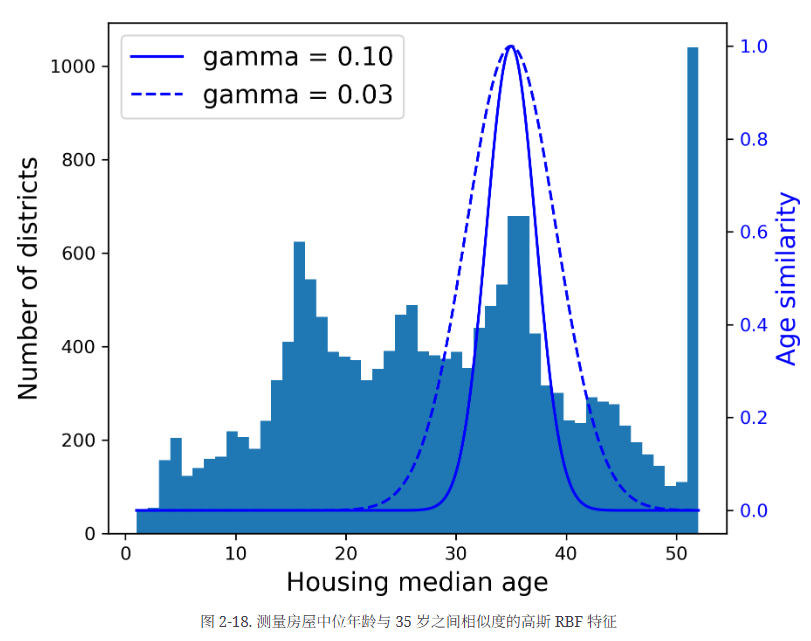

到目前为止，我们只研究了输入特征，但目标值可能也需要进行转换。例如，如果目标值分布 尾部较重，您可以选择用其对数代替目标值。但如果这样做，回归模型现在预测的将是房屋价值中位数的对数，而不是房屋价值中位数本身。如果你想得到预测的房屋价值中位数，就需要计算模型预测值的指数。

幸运的是，Scikit-Learn 的大多数变换器都有inverse_transform() 方法，因此可以轻松计算其变换的逆值。例如，下面的代码示例展示了如何使用StandardScaler 对标签进行缩放（就像我们对输入所做的那样），然后在缩放后的标签上训练一个简单的线性回归模型，并用它对一些新数据进行预测，我们再使用训练好的缩放器的inverse_transform() 方法将其转换回原始缩放。请注意，我们将标签从 Pandas Series 转换为 DataFrame ，因为StandardScaler 希望使用二维输入。此外，在本示例中，为了简单起见，我们只用一个原始输入特征（收入中位数）来训练模型 ：

In [ ]:
# from sklearn.linear_model import LinearRegression

# target_scaler = StandardScaler()
# scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())#因为 scikit-learn 的设计要求：所有输入必须是二维结构，所以用to_frame()来从一位到二维

# model = LinearRegression()
# model.fit(housing[["median_income"]], scaled_labels)
# some_new_data = housing[["median_income"]].iloc[:5]  # pretend this is new data

# scaled_predictions = model.predict(some_new_data)
# predictions = target_scaler.inverse_transform(scaled_predictions)

In [ ]:
#也可以用更简单的方式
# from sklearn.compose import TransformedTargetRegressor

# model = TransformedTargetRegressor(LinearRegression(),transformer=StandardScaler())
# model.fit(housing[["median_income"]], housing_labels)
# predictions = model.predict(some_new_data)

"""
它将自动使用转换器缩放标签，并根据缩放后的标签训练回归模型，就像我们之前所做的那样。
然后，当我们要进行预测时，它会调用回归模型的predict()方法，并使用缩放器的inverse_transform()方法生成预测结果
"""

自定义变换器
虽然 Scikit-Learn 提供了许多有用的转换器，但您偶尔也需要编写自己的转换器来完成自定义转换、清理操作或组合特定属性等任务。

对于不需要任何训练的转换，你只需编写一个接收 NumPy 数组作为输入并输出转换后数组的函数即可。例如，正如上一节所讨论的，用对数代替重尾分布（假设特征为正且尾部在右侧）来转换特征通常是个好主意。让我们创建一个对数变换器 ，并将其应用于population 特征 ：

In [ ]:
# from sklearn.preprocessing import FunctionTransformer

# log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
# log_pop = log_transformer.transform(housing[["population"]])

#inverse_func 参数是可选的。它可以让你指定一个反变换函数，例如，如果你打算在TransformedTargetRegressor 中使用你的变换器。

# rbf_transformer = FunctionTransformer(rbf_kernel,kw_args=dict(Y=[[35.]], gamma=0.1))
# age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [ ]:
# sf_coords = 37.7749, -122.41
# sf_transformer = FunctionTransformer(rbf_kernel,kw_args=dict(Y=[sf_coords], gamma=0.1))
# sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

自定义变换器对组合特征也很有用。例如，下面的FunctionTransformer 可以计算输入特征 0 和 1 之间的比率：

>>> ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
>>> ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))
array([[0.5 ],
       [0.75]])

# FunctionTransformer这很方便，但如果你希望你的变换器是可训练的，在fit() 方法中学习一些参数，然后在transform() 方法中使用这些参数呢？为此，您需要编写一个自定义类。

# 注
# 本节其余部分将展示如何定义自定义变换器类。特别是，它定义了一个自定义变换器，将各区分为 10 个地理聚类，然后测量每个区与每个聚类中心之间的距离，并为数据添加 10 个相应的 RBF 相似性特征。由于定义自定义变换器类有些高深，请随时跳到下一节，需要时再回来。

In [ ]:
#我先跳过了

转换管道
正如 所示，有许多数据转换步骤需要按照正确的顺序执行。幸运的是，Scikit-Learn 提供了Pipeline 类 来帮助处理此类转换顺序。下面是一个针对数值属性的小型管道，它将首先计算输入特征，然后缩放 ：

In [1]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

NameError: name 'SimpleImputer' is not defined

In [ ]:
>>> housing_num_prepared = num_pipeline.fit_transform(housing_num)
>>> housing_num_prepared[:2].round(2)

如前所述，如果想恢复一个漂亮的 DataFrame，可以使用管道的get_feature_names_out() 方法：

In [ ]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

Pipeline 构造函数 接收一个名称/估计器对（2 元组）列表，定义一系列步骤。名称可以是任何你喜欢的，只要它们是唯一的，并且不包含双下划线 (__)。稍后我们讨论超参数调整时，这些名称将非常有用。除了最后一个估计器，其他估计器都必须是变换器（即必须有fit_transform() 方法），变换器、预测器或其他任何类型的估计器都可以。

提示
在 Jupyter 笔记本中，如果import sklearn 并运行sklearn.​set_config(display="diagram") ，所有 Scikit-Learn 估算器都将呈现为交互式图表。这对可视化管道特别有用。要可视化num_pipeline ，请运行num_pipeline 作为最后一行的单元格。点击估计器将显示更多细节。

如果不想为变换器命名，可以使用方便的make_pipeline() 函数；该函数将变换器作为位置参数，并使用变换器的类名（小写且不带下划线）创建Pipeline （例如"simpleimputer" ）：

In [ ]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

管道支持索引；例如，pipeline[1] 返回管道中的第二个估算器，而pipeline[:-1] 返回一个Pipeline 对象，其中包含除最后一个估算器之外的所有估算器。您还可以通过steps 属性（即名称/估算器对列表）或named_steps 字典属性（将名称映射到估算器）访问估算器。例如，num_pipeline["simpleimputer"] 返回名为"simpleimputer" 的估计器。

到目前为止，我们已经分别处理了分类列和数字列。更方便的做法是使用一个转换器来处理所有列，并对每一列应用适当的转换。为此，您可以使用ColumnTransformer 。例如，下面的ColumnTransformer 将对数字属性应用num_pipeline （我们刚刚定义的那个），对分类属性应用cat_pipeline ：

In [ ]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),#num_pipeline是在上个code cell中命名的
    ("cat", cat_pipeline, cat_attribs),
])

不是重命名，这里很多人会误解 👍
第三个参数其实是：“这个 pipeline 要处理哪些列”

我们一步一步拆开：

🧠 1️⃣ ColumnTransformer 的结构
ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

每一项其实是一个三元组：

(name, transformer, columns)

当然对于我们并不知道列类别的分布情况下，可以选择一个选择器Selecter来完成对不同类型列的自动选择

In [ ]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

现在，我们可以将ColumnTransformer 应用于房屋数据了：

In [ ]:
housing_prepared = preprocessing.fit_transform(housing)

您的项目进展非常顺利，几乎可以训练一些模型了！现在你要创建一个单一的管道，来执行你之前试验过的所有转换。让我们来回顾一下管道的作用和原因：

数值特征中的缺失值将用中位数来代替，因为大多数 ML 算法都不希望出现缺失值。在分类特征中，缺失值将用最常出现的类别来替代。

分类特征将进行单次编码，因为大多数 ML 算法只接受数值输入。

将计算并添加一些比率特征：bedrooms_ratio 、rooms_​per_house 和people_per_house 。希望这些特征能更好地与房屋价值中位数相关，从而有助于 ML 模型。

还将添加一些群集相似性特征。这些特征可能比经度和纬度对模型更有用。

尾部较长的特征将用其对数代替，因为大多数模型更喜欢大致均匀分布或高斯分布的特征。

所有数字特征都将标准化，因为大多数 ML 算法更喜欢所有特征的比例大致相同。

现在，构建管道以完成所有这些工作的代码对你来说应该很熟悉了：

# 现在可以开始整体流程了

In [ ]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # feature names out

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline(), ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # one column remaining: housing_median_age

In [ ]:
>>> housing_prepared = preprocessing.fit_transform(housing)
>>> housing_prepared.shape
(16512, 24)
>>> preprocessing.get_feature_names_out()
#结果示例
array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity', [...],
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

# 选择并训练模型
最后， ！您确定了问题的框架，获得了数据并对其进行了探索，对训练集和测试集进行了采样，并编写了预处理管道来自动清理数据并为机器学习算法做好准备。现在，您已经准备好选择和训练机器学习模型了。

# 在训练集上进行训练和评估
好消息是，有了前面的这些步骤，现在一切都变得简单了！您决定训练一个非常基本的线性回归模型 开始 ：

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

完成！现在您已经有了一个可用的线性回归模型。您可以在训练集上进行尝试，查看前五个预测结果，并将它们与标签进行比较：

In [ ]:
>>> housing_predictions = lin_reg.predict(housing)
>>> housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

>>> housing_labels.iloc[:5].values


In [ ]:
>>> from sklearn.metrics import root_mean_squared_error
>>> lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
>>> lin_rmse
68972.88910758484

您决定尝试DecisionTreeRegressor ，因为这是一个相当强大的模型，能够发现数据中复杂的非线性关系（决策树 将在第 5 章中详细介绍）：

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

In [ ]:
>>> housing_predictions = tree_reg.predict(housing)
>>> tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
>>> tree_rmse
0.0

等等，什么？完全没有错误？这个模型真的绝对完美吗？当然，更有可能的是模型严重过拟合数据。你怎么能确定呢？正如你之前看到的，在你准备好推出一个你有信心的模型之前，你不想接触测试集，所以你需要使用部分训练集进行训练，部分训练集进行模型验证。

# 使用交叉验证进行更好的评估
评估决策树模型的一种方法是使用train_​test_split() 函数将训练集分成较小的训练集和验证集，然后根据较小的训练集训练模型，再根据验证集评估模型。这有点费力，但并不难，而且效果相当不错。

一个很好的替代方法是使用 Scikit-Learn 的k 折交叉验证 功能。您可以将训练集分成k 个不重叠的子集，称为折叠 ，然后对模型进行k次训练和评估，每次选择一个不同的折叠进行评估（即验证折叠），并使用其他k- 1 个折叠进行训练。这个过程会产生k 个评估分数

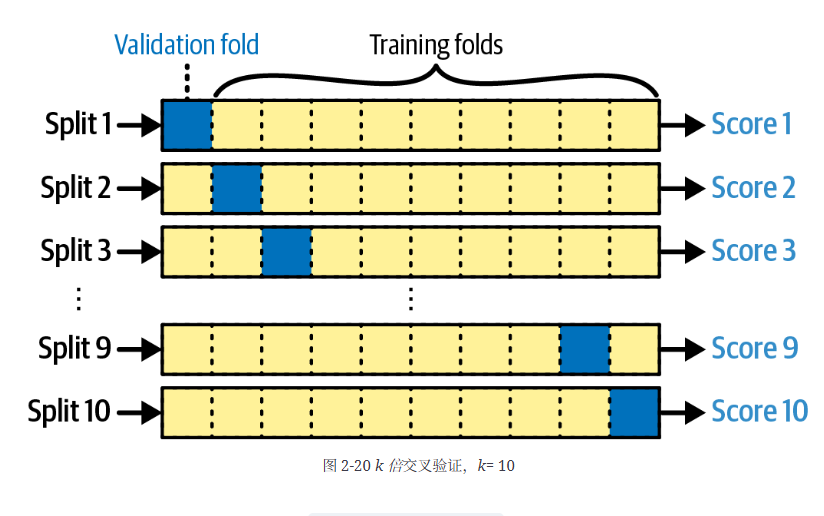

Scikit-Learn 提供了一个方便的cross_val_score() 函数，可以实现上述功能，并返回一个包含k 个评估分数的数组。例如，让我们用它来评估我们的树回归器，使用k= 10 ：

In [ ]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

**警告**
Scikit-Learn 的交叉验证功能期望的是效用函数（越大越好）而不是成本函数（越低越好），因此评分函数实际上与 RMSE 相反。它是一个负值，所以你需要转换输出的符号来获得 RMSE 分数。

In [ ]:
>>> pd.Series(tree_rmses).describe()
count       10.000000
mean     66573.734600
std       1103.402323
min      64607.896046
25%      66204.731788
50%      66388.272499
75%      66826.257468
max      68532.210664
dtype: float64

现在我们来试试最后一个模型：RandomForestRegressor 。正如我们在第 6 章中看到的，随机森林的工作原理是在随机特征子集上训练许多决策树，然后平均它们的预测结果。这种由许多其他模型组成的模型被称为集合 ： ，如果底层模型非常多样化，那么它们的误差就不会有很大的相关性，因此平均化预测结果可以平滑误差，减少过拟合，提高整体性能。代码与之前的大致相同：

In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [ ]:
>>> pd.Series(forest_rmses).describe()
count       10.000000
mean     47038.092799
std       1021.491757
min      45495.976649
25%      46510.418013
50%      47118.719249
75%      47480.519175
max      49140.832210
dtype: float64

# **微调模型**
让我们在 上假设您现在已经有了一份有希望的模型候选名单。现在，您需要对它们进行微调。让我们来看看实现这一目标的几种方法。

# **网格搜索**
的一个选择是手动调整超参数 ，直到找到超参数值的最佳组合。这将是一项非常乏味的工作，而且您可能没有时间探索多种组合。

相反，您可以使用 Scikit-Learn 的GridSearchCV 类为您搜索。你只需告诉它你希望它尝试哪些超参数以及尝试哪些值，它就会使用交叉验证来评估所有可能的超参数值组合。例如，下面的代码为RandomForestRegressor 搜索超参数值的最佳组合：

In [ ]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

请注意，您可以引用管道中任何估计器的任何超参数，即使该估计器嵌套在多个管道和列转换器中。例如，当 Scikit-Learn 看到"preprocessing__geo__n_clusters" 时，它会在双下划线处分割这个字符串，然后查找管道中名为"preprocessing"的估计器，并找到预处理ColumnTransformer 。接下来，它会在ColumnTransformer 中查找名为"geo" 的转换器，并找到我们在经纬度属性上使用的ClusterSimilarity 转换器。然后找到该转换器的n_clusters 超参数。同样，random_forest__max_features 指的是名为"random_forest" 的估计器的max_features 超参数，这当然是RandomForestRegressor 模型（max_features 超参数将在第 6 章解释）。

In [ ]:
>>> grid_search.best_params_
{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

您可以使用grid_search.best_estimator_ 访问最佳估计器。如果Grid​SearchCV 用refit=True 进行初始化（这是默认设置），那么一旦它通过交叉验证找到最佳估计器，就会在整个训练集上重新训练它。这通常是个好主意，因为向它提供更多数据可能会提高其性能。

评估分数可通过grid_search.cv_results_ 获取。这是一个字典，但如果将其封装在 DataFrame 中，就能得到一个漂亮的列表，其中包含每个超参数组合和每个交叉验证拆分的所有测试得分，以及所有拆分的平均测试得分：

In [ ]:
>>> cv_res = pd.DataFrame(grid_search.cv_results_)
>>> cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
>>> [...]  # change column names to fit on this page, and show rmse = -score
>>> cv_res.head()  # note: the 1st column is the row ID
    n_clusters  max_features  split0  split1  split2  mean_test_rmse
12          15             6   42725   43708   44335           43590
13          15             8   43486   43820   44900           44069
6           10             4   43798   44036   44961           44265
9           10             6   43710   44163   44967           44280
7           10             6   43710   44163   44967           44280

# **启动、监控和维护您的系统**
完美 ，您获得了启动批准！现在，您需要为生产准备好解决方案（例如，完善代码、编写文档和测试等）。然后，您就可以将模型部署到生产环境中。最基本的方法是保存您训练有素的最佳模型，将文件传输到生产环境并加载它。要保存模型，可以像这样使用joblib 库 ：

In [ ]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

提示
保存每个实验模型通常是个好主意，这样您就可以很容易地返回到任何您想要的模型。您还可以保存交叉验证得分，或许还可以保存验证集上的实际预测结果。这样您就可以轻松比较不同模型类型的得分，并比较它们所犯的错误类型。

将模型传输到生产环境后，就可以加载并使用模型了。为此，您必须首先导入模型所依赖的任何自定义类和函数（这意味着将代码转移到生产环境中），然后使用joblib 加载模型并使用它进行预测：

In [ ]:
import joblib
[...]  # import KMeans, BaseEstimator, TransformerMixin, rbf_kernel, etc.

def column_ratio(X): [...]
def ratio_name(function_transformer, feature_names_in): [...]
class ClusterSimilarity(BaseEstimator, TransformerMixin): [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = [...]  # some new districts to make predictions for
predictions = final_model_reloaded.predict(new_data)

练习
以下练习基于本章的住房数据集：

尝试使用支持向量机回归器 (sklearn.svm.SVR) 和不同的超参数，如kernel="linear" （使用C 超参数的不同值）或kernel="rbf" （使用C 和gamma 超参数的不同值）。请注意，支持向量机不能很好地扩展到大型数据集，所以你可能应该只在训练集的前 5,000 个实例上训练你的模型，并且只使用 3 倍交叉验证，否则将耗费数小时。暂时不用担心超参数的含义，https://homl.info/ 上关于 SVM 的在线章节会有解释。最好的SVR 预测器表现如何？

尝试将GridSearchCV 替换为RandomizedSearchCV 。

尝试在准备管道中添加SelectFromModel 转换器，以便只选择最重要的属性。

尝试创建一个自定义转换器，在其fit() 方法中训练K 近邻回归器 (sklearn.neighbors.KNeighborsRegressor)，并在其transform() 方法中输出模型的预测结果。KNN 回归器应该只使用经纬度作为输入，并预测收入中位数。接下来，将这个新的转换器添加到预处理管道中。这将添加一个代表附近地区平滑收入中位数的特征。

使用RandomizedSearchCV 自动探索一些准备选项。

尝试从头开始再次实现StandardScalerClone 类，然后添加对inverse_transform() 方法的支持：执行scaler.​inverse_transform(scaler.fit_transform(X)) 应返回一个非常接近X 的数组。然后添加对特征名称的支持：如果输入是 DataFrame，则在fit() 方法中设置feature_names_in_ 。该属性应为列名的 NumPy 数组。最后，实现get_feature_names_out() 方法：它应该有一个可选的input_features=None 参数。如果传入，该方法应检查其长度是否与n_features_in_ 匹配，如果定义了feature_names_in_ ，则应与之匹配；然后返回input_features 。如果input_features 是None ，那么该方法应返回feature_names_in_否则返回np.array(["x0", "x1", ...]) ，长度为n_features_in_ 。

按照本章所学的过程，完成你选择的回归任务。例如，您可以尝试处理车辆数据集，其目标是根据车龄、行驶公里数、品牌和车型等因素预测一辆二手车的售价。另一个值得一试的数据集是共享单车数据集：目标是根据一周中的哪一天、时间和天气条件，预测一段时间内（列cnt ）自行车的租赁数量。

这些练习的解答可在本章笔记本的末尾找到，网址是https://homl.info/colab-p。

1原始数据集出现在 R. Kelley Pace 和 Ronald Barry 合著的《稀疏空间自回归》（SparseSpatialAutoregressions）一书中。3 (1997):291-297.

2输入机器学习系统的信息通常被称为信号，这与克劳德-香农的信息论有关，他在贝尔实验室提出这一理论是为了改进电信。他的理论是：你需要高信噪比。

3回想一下，转置算子 可以将列向量翻转成行向量（反之亦然）。

4您可能还需要检查法律约束，例如绝不能复制到不安全数据存储区的私有字段。

5标准偏差 一般用σ（希腊字母 sigma）表示，它是方差的平方根，而方差是与均值的平方差的平均值。当某一特征具有钟形正态分布（也称为高斯分布）时（这很常见），"68-95-99.7 "规则适用：约 68% 的值落在均值的1σ以内，95% 落在2σ 以内，99.7% 落在3σ 以内。

6你经常会看到有人将随机种子设置为 42。这个数字除了是生命、宇宙和万物终极问题的答案之外，并没有其他特殊属性。

7地理位置信息实际上非常粗略，因此许多地区的 ID 完全相同，所以它们最终会出现在同一个集合（测试集或训练集）中。这带来了一些不幸的抽样偏差。

8如果您正在阅读灰度版本，请用红色笔涂抹从湾区到圣地亚哥的大部分海岸线（如您所料）。您还可以在萨克拉门托周围加上一片黄色。

9有关设计原则的更多详情，请参阅 Lars Buitinck 等人的文章《机器学习软件的 API 设计》（API Design for Machine Learning Software）：来自 Scikit-Learn 项目的经验"，arXiv preprint arXiv:1309.0238 (2013)。

10一些预测器还提供了衡量预测置信度的方法。

11如果运行sklearn.set_config(transform_output="pandas") ，所有转换器在接收到 DataFrame 作为输入时都将输出 Pandas DataFrames：Pandas in, Pandas out。

12详情请参见 SciPy 文档。

13使用鸭子类型 时，重要的是对象的方法和行为，而不是其类型："如果它看起来像鸭子，叫起来像鸭子，那它一定是鸭子。

14简而言之，REST（或 RESTful）API是一种基于 HTTP 的 API，它遵循一些约定，如使用标准 HTTP 动词来读取、更新、创建或删除资源（GET、POST、PUT 和 DELETE），并使用 JSON 作为输入和输出。

15验证码 是一种确保用户不是机器人的测试。这些测试通常被用作标注训练数据的廉价方法。